# Модуль 15. Математика под микроскопом: функции, пределы, производные, интегралы, ряды, ДУ, линейная алгебра, вероятности, статистика, оптимизация, информация, комбинаторика, графы, логика, теория чисел, теория игр

**Интерактивная версия:** `lessons/lesson_15/web/index.html`

Глава строит математику градиентного бустинга с нуля. Читать можно по порядку или выборочно.

| Урок | Тема | Ноутбук |
|---|---|---|
| 15.1 | Функция и её график | `lesson_15_1/jupyter_notebooks/lesson_15_1_functions.ipynb` |
| 15.2 | Скорость изменения: от средней к мгновенной | `lesson_15_2/jupyter_notebooks/lesson_15_2_rate_of_change.ipynb` |
| 15.3 | Пределы: подходим всё ближе | `lesson_15_3/jupyter_notebooks/lesson_15_3_limits.ipynb` |
| 15.4 | Техника пределов и непрерывность | `lesson_15_4/jupyter_notebooks/lesson_15_4_limit_techniques.ipynb` |
| 15.5 | Производная | `lesson_15_5/jupyter_notebooks/lesson_15_5_derivative.ipynb` |
| 15.6 | Правила дифференцирования | `lesson_15_6/jupyter_notebooks/lesson_15_6_differentiation_rules.ipynb` |
| 15.7 | Вторая производная, выпуклость, Тейлор и Ньютон | `lesson_15_7/jupyter_notebooks/lesson_15_7_second_order.ipynb` |
| 15.8 | Много переменных: частные производные и градиент | `lesson_15_8/jupyter_notebooks/lesson_15_8_gradient.ipynb` |
| 15.9 | Интегралы: площадь, накопление и вероятность | `lesson_15_9/jupyter_notebooks/lesson_15_9_integrals.ipynb` |
| 15.10 | Ряды: бесконечные суммы | `lesson_15_10/jupyter_notebooks/lesson_15_10_series.ipynb` |
| 15.11 | Дифференциальные уравнения: законы изменения | `lesson_15_11/jupyter_notebooks/lesson_15_11_differential_equations.ipynb` |
| 15.12 | Линейная алгебра: векторы, матрицы, проекции | `lesson_15_12/jupyter_notebooks/lesson_15_12_linear_algebra.ipynb` |
| 15.13 | Теория вероятностей: случайность под контролем | `lesson_15_13/jupyter_notebooks/lesson_15_13_probability.ipynb` |
| 15.14 | Математическая статистика: выводы по данным | `lesson_15_14/jupyter_notebooks/lesson_15_14_statistics.ipynb` |
| 15.15 | Оптимизация: как искать лучшее | `lesson_15_15/jupyter_notebooks/lesson_15_15_optimization.ipynb` |
| 15.16 | Теория информации: биты, энтропия, перекрёстная энтропия | `lesson_15_16/jupyter_notebooks/lesson_15_16_information.ipynb` |
| 15.17 | Комбинаторика: искусство считать варианты | `lesson_15_17/jupyter_notebooks/lesson_15_17_combinatorics.ipynb` |
| 15.18 | Теория графов: вершины, рёбра, деревья | `lesson_15_18/jupyter_notebooks/lesson_15_18_graphs.ipynb` |
| 15.19 | Математическая логика: высказывания, кванторы, доказательства | `lesson_15_19/jupyter_notebooks/lesson_15_19_logic.ipynb` |
| 15.20 | Теория чисел: остатки, простые, генераторы | `lesson_15_20/jupyter_notebooks/lesson_15_20_number_theory.ipynb` |
| 15.21 | Теория игр: стратегии, равновесия, Шепли | `lesson_15_21/jupyter_notebooks/lesson_15_21_game_theory.ipynb` |

Ниже — сквозной пример главы в пяти строках: функция → предел → производная → градиент → бустинг.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np

from gbcourse import datasets
from gbcourse.plotting import use_course_style
from gbcourse.style import BLUE, ORANGE

use_course_style()

## Наклон касательной в разных точках

На подъёмах наклон положительный, на спусках отрицательный, на вершинах и в ямах — около нуля.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


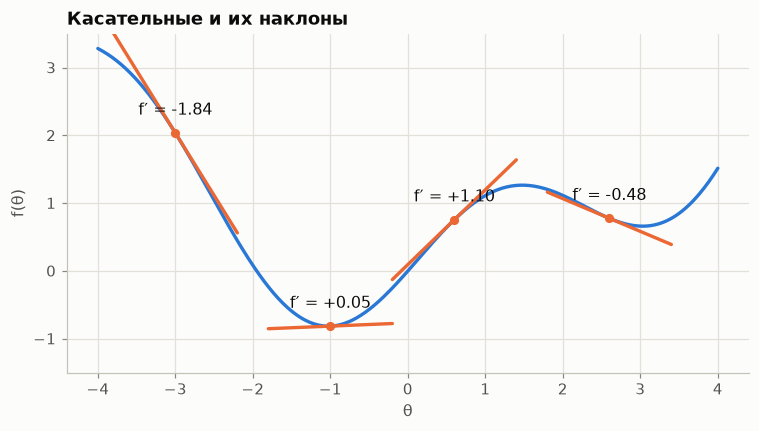

In [2]:
f = lambda t: np.sin(1.3 * t) + 0.15 * t**2   # noqa: E731
df = lambda t: 1.3 * np.cos(1.3 * t) + 0.3 * t  # noqa: E731

x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, f(x), color=BLUE, lw=2.2, label="f(θ)")
for t0 in (-3.0, -1.0, 0.6, 2.6):
    seg = np.array([t0 - 0.8, t0 + 0.8])
    ax.plot(seg, f(t0) + df(t0) * (seg - t0), color=ORANGE, lw=2.2)
    ax.plot([t0], [f(t0)], "o", color=ORANGE)
    ax.annotate(f"f′ = {df(t0):+.2f}", (t0, f(t0)), textcoords="offset points", xytext=(0, 12), ha="center")
ax.set(xlabel="θ", ylabel="f(θ)", ylim=(-1.5, 3.5), title="Касательные и их наклоны")
plt.show()

## Вся глава в пяти строках

Потери шести квартир как функция вектора прогнозов; производная — через предел (центральная разность);
антиградиент — остатки; шаг по нему уменьшает потери.

In [3]:
_, y = datasets.toy_regression()
L = lambda F: 0.5 * np.sum((y - F) ** 2)                                    # noqa: E731  функция (15.1)
F = np.full_like(y, y.mean())
h = 1e-6
grad = np.array([(L(F + h * e) - L(F - h * e)) / (2 * h) for e in np.eye(6)])  # предел и частные производные (15.3, 15.8)
print("потери:", L(F), "| градиент:", grad.round(6), "| антиградиент = остатки:", np.allclose(-grad, y - F))
print("шаг против градиента с η = 0.5: потери", L(F - 0.5 * grad))

потери: 32.0 | градиент: [ 4.  2.  3. -1. -3. -5.] | антиградиент = остатки: True
шаг против градиента с η = 0.5: потери 7.999999994654928
